# Libraries and functions

In [9]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_err_vs_norm_all_curves(
    data,
    norm_type="spectral_complexity",
    y_plot = "error",
    ax=None,
    figsize=(7, 5),
    lw=1.2,
    alpha=0.9,
    use_log_color=True,
    xscale="linear",
    yscale="linear",
    add_colorbar=True,
    title=None,
):
    """
    Plot all seed curves of test error vs norm during training.

    Parameters
    ----------
    data : dict
        Already loaded npy dictionary, e.g.
        data = np.load(path, allow_pickle=True).item()

    norm_type : str
        "spectral_complexity" or "l2" or "time"

    ax : matplotlib axis or None
        If None, create a new figure.

    figsize : tuple
        Figure size if ax is None.

    lw : float
        Line width.

    alpha : float
        Curve transparency.

    use_log_color : bool
        If True, color mapping in P uses LogNorm.
        If False, uses linear Normalize.

    xscale, yscale : str
        Axis scales, e.g. "linear" or "log".

    add_colorbar : bool
        Whether to add the colorbar.

    title : str or None
        Optional custom title.

    Returns
    -------
    fig, ax
    """
    P_values = np.asarray(data["P_values"])
    if y_plot == "error":
        err_seeds = np.asarray(data["err_seeds"])   # shape (nP, nT, nS)
        ylabel = "test error"
    elif y_plot == "spectral_complexity":
        err_seeds = np.asarray(data["spectral_seeds"])
        ylabel = "spectral complexity norm"
    elif y_plot == "spectral_complexity_no_QK":
        err_seeds = np.asarray(data["spectral_no_qk_seeds"])
        ylabel = "spectral complexity norm"
    elif y_plot == "l2":
        err_seeds = np.asarray(data["l2_seeds"])
        ylabel = "L2 norm"
    num_seeds = np.asarray(data["num_seeds"])   # shape (nP,)

    if norm_type == "spectral_complexity":
        norm_seeds = np.asarray(data["spectral_seeds"])
        xlabel = "spectral complexity norm"
    if norm_type == "spectral_complexity_no_QK":
        norm_seeds = np.asarray(data["spectral_no_qk_seeds"])
        xlabel = "spectral complexity norm"
    elif norm_type == "l2":
        norm_seeds = np.asarray(data["l2_seeds"])
        xlabel = "L2 norm"
    elif norm_type == "time":
        norm_seeds = np.asarray(data["T_arr"])
        norm_seeds = np.broadcast_to(
            norm_seeds[None, :, None],
            (err_seeds.shape[0], norm_seeds.shape[0], err_seeds.shape[2])
        )
        xlabel = "t"
    else:
        raise ValueError("norm_type must be 'spectral_complexity' or 'l2' or 'time'")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    cmap = mpl.cm.get_cmap("viridis")

    if len(P_values) == 1:
        def color_of_P(P):
            return cmap(1.)
        sm = None
    else:
        if use_log_color:
            color_norm = mpl.colors.LogNorm(vmin=np.min(P_values), vmax=np.max(P_values)+1000)
        else:
            color_norm = mpl.colors.Normalize(vmin=np.min(P_values), vmax=np.max(P_values))

        def color_of_P(P):
            return cmap(color_norm(P))

        sm = mpl.cm.ScalarMappable(norm=color_norm, cmap=cmap)
        sm.set_array([])

    nP, nT, nS = err_seeds.shape

    for iP in range(nP):
        P = P_values[iP]
        this_color = color_of_P(P)

        # use only true seeds for this P
        for iseed in range(num_seeds[iP]):
            x = norm_seeds[iP, :, iseed]
            if norm_type == "time":
                x = norm_seeds[iP, :, iseed] / (128./P)
            y = err_seeds[iP, :, iseed]

            mask = np.isfinite(x) & np.isfinite(y)

            # for log x/y, remove non-positive values
            if xscale == "log":
                mask &= (x > 0)
            if yscale == "log":
                mask &= (y > 0)

            if np.sum(mask) < 2:
                continue

            ax.plot(
                x[2:],
                y[2:],
                color=this_color,
                lw=lw,
                alpha=alpha,
            )

    ax.set_xlabel(xlabel , fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and sm is not None:
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("P")

    plt.tight_layout()
    return fig, ax

# Replicate paper curve

In [2]:
res = np.load("results/exp_base_v5.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152]
epochs: [ 0  1  2  3  5  6  7 10 20 25 30 40 50 60 64]
num seeds: [3 3 3 3 3 3 3 3]
fixed params: {'dataset': 'rhm', 'mode': 'masked', 'num_features': 32, 'num_classes': 32, 'num_synonyms': 8, 'tuple_size': 2, 'num_layers': 3, 'path': None, 'num_tokens': 8, 'batch_size': 128, 'test_size': 32768, 'input_form

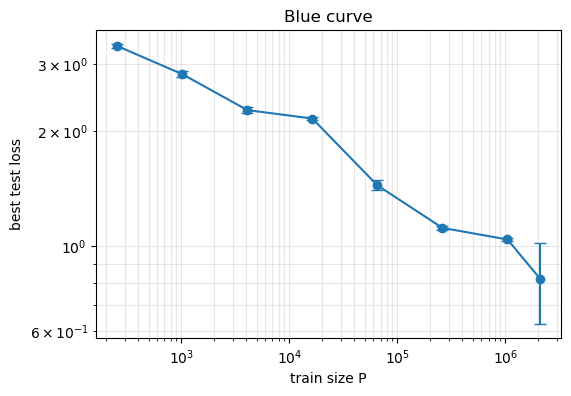

In [4]:
P = res["P_values"]
y = res["best_loss_mean"]
yerr = np.where(res["best_loss_std"] < 0, 0.0, res["best_loss_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("train size P")
plt.ylabel("best test loss")
plt.title("Blue curve")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Study of the norm

# Init scale = 0.8

### No Q,K

In [2]:
res = np.load("results/exp_base_v13.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152 4194304]
epochs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47

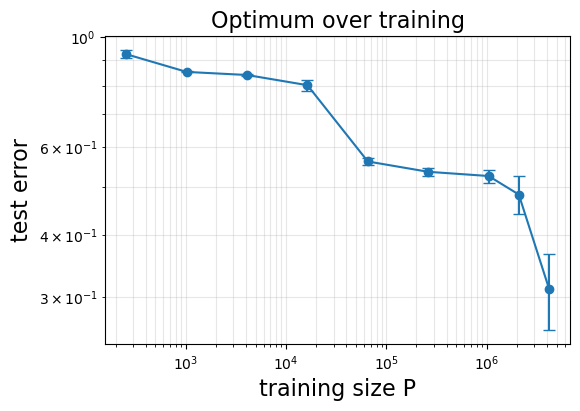

In [16]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_13394/2478624447.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

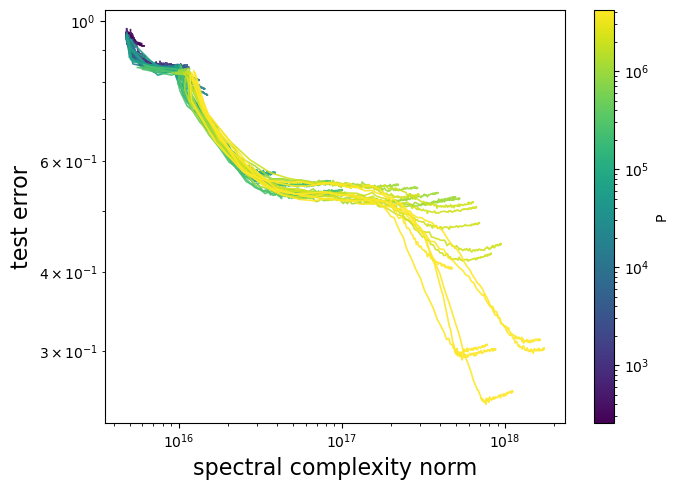

In [10]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity_no_QK",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_13394/2478624447.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

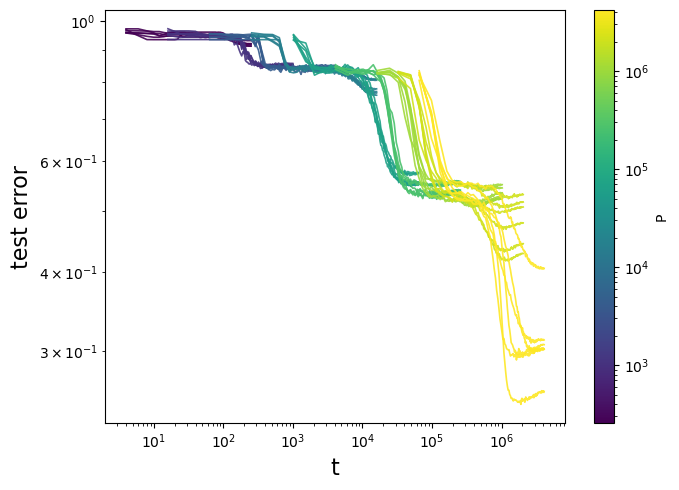

In [11]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_13394/4108429274.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

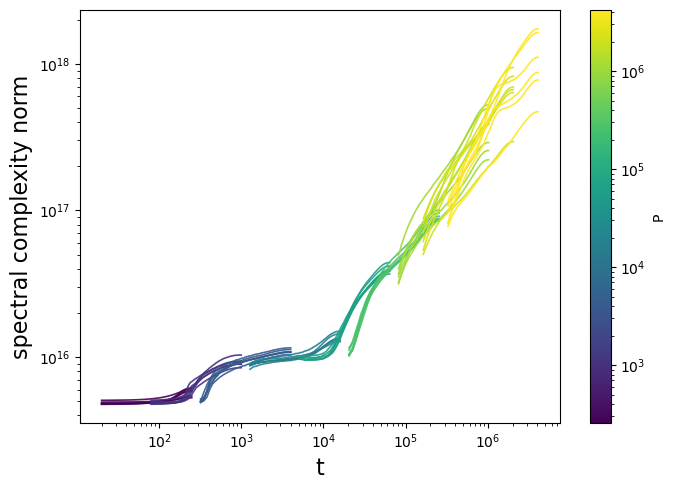

In [8]:
plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity_no_QK",
    norm_type="time",
    xscale="log",
    yscale="log",
)


### With Q,K

In [18]:
res = np.load("results/exp_base_v12.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'err_seeds', 'spectral_seeds', 'spectral_no_qk_raw', 'spectral_no_qk_seeds', 'l2_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152 4194304]
epochs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47

In [ ]:
P = res["P_values"]
y = res["best_acc_mean"]
yerr = np.where(res["best_acc_std"] < 0, 0.0, res["best_acc_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, 1-y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("training size P", fontsize=16)
plt.ylabel("test error", fontsize=16)
plt.title("Optimum over training", fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='spectral complexity norm', ylabel='test error'>)

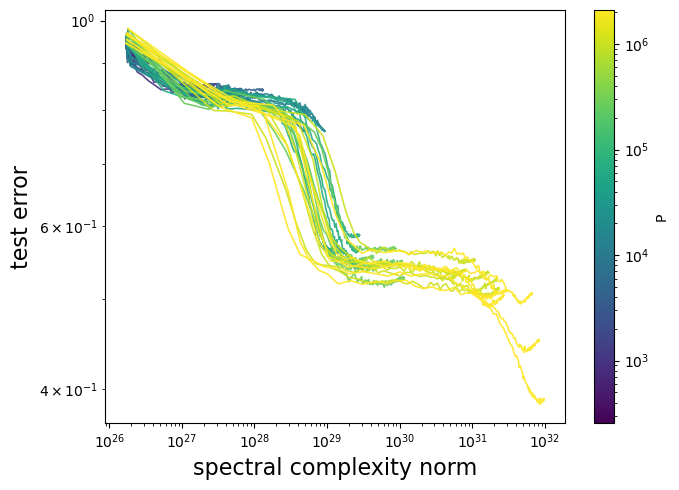

In [39]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='L2 norm', ylabel='test error'>)

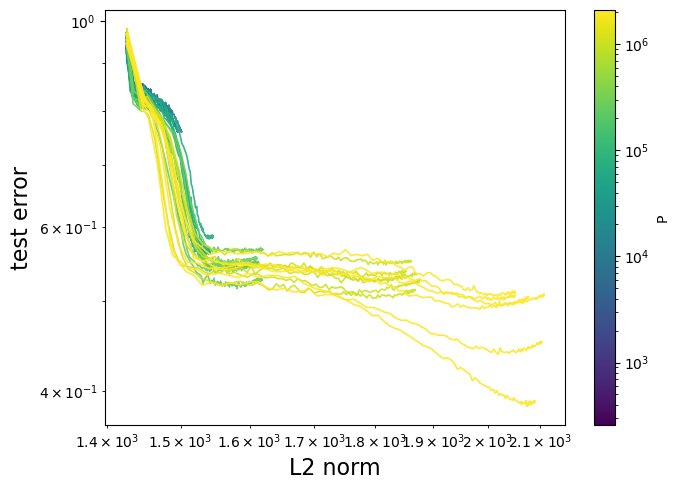

In [40]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="l2",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='test error'>)

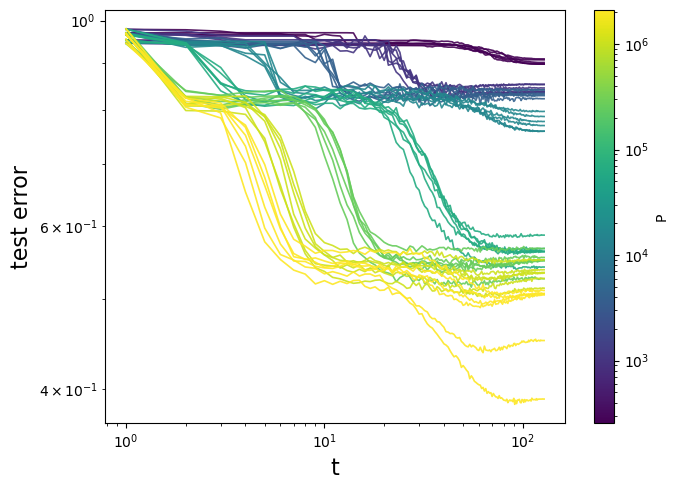

In [41]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="time",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/652435549.py:94: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: xlabel='t', ylabel='spectral complexity norm'>)

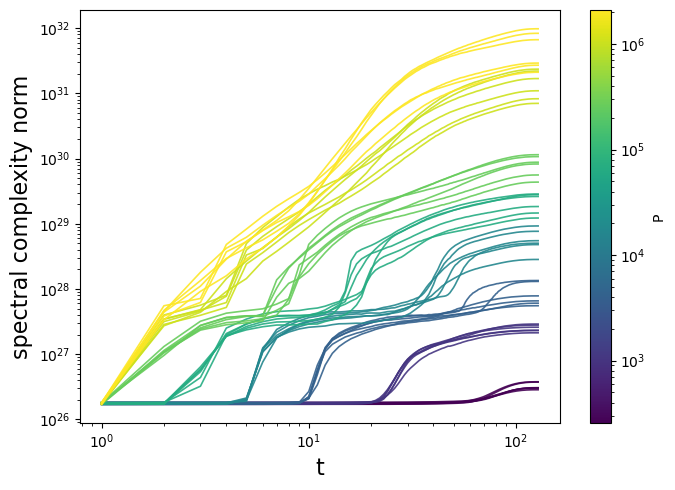

In [42]:


plot_err_vs_norm_all_curves(
    res,
    y_plot = "spectral_complexity",
    norm_type="time",
    xscale="log",
    yscale="log",
)


/tmp/ipykernel_4656/1450215154.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>, <Axes: xlabel='t', ylabel='L2 norm'>)

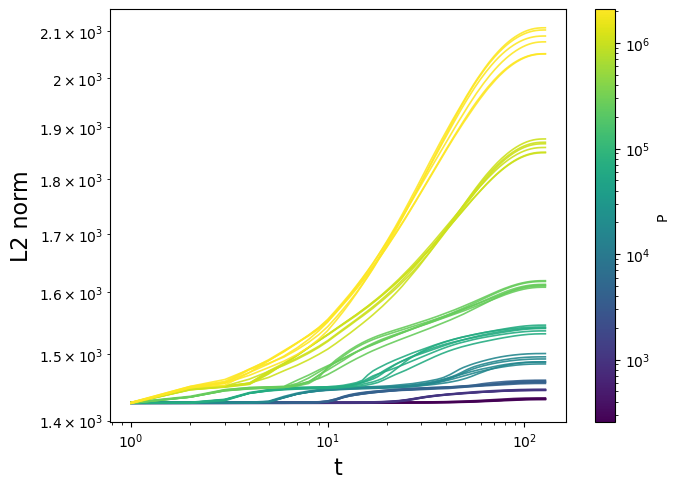

In [44]:


plot_err_vs_norm_all_curves(
    res,
    y_plot = "l2",
    norm_type="time",
    xscale="log",
    yscale="log",
)


## Init scale = 1.0

In [4]:
res = np.load("results/exp_base_v10.npy", allow_pickle=True).item()

print(res.keys())
print("P values:", res["P_values"])
print("epochs:", res["epoch_values"])
print("num seeds:", res["num_seeds"])
print("fixed params:", res["fixed_params"].item())

dict_keys(['run_name', 'experiment_name', 'fixed_params', 'P_values', 'epoch_values', 'T_arr', 'num_seeds', 'seed_triplets', 'trainloss_raw', 'testloss_raw', 'testacc_raw', 'err_seeds', 'spectral_seeds', 'l2_seeds', 'trainloss_mean', 'trainloss_std', 'trainloss_n', 'testloss_mean', 'testloss_std', 'testloss_n', 'testacc_mean', 'testacc_std', 'testacc_n', 'best_loss_raw', 'best_acc_raw', 'best_epoch_raw', 'last_saved_epoch_raw', 'best_loss_mean', 'best_loss_std', 'best_loss_n', 'best_acc_mean', 'best_acc_std', 'best_acc_n', 'best_epoch_mean', 'best_epoch_std', 'best_epoch_n', 'last_saved_epoch_mean', 'last_saved_epoch_std', 'last_saved_epoch_n', 'file_index'])
P values: [    256    1024    4096   16384   65536  262144 1048576 2097152]
epochs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]
num seeds: [5 5 5 5 5 5 5 5]
fixed params: {'data

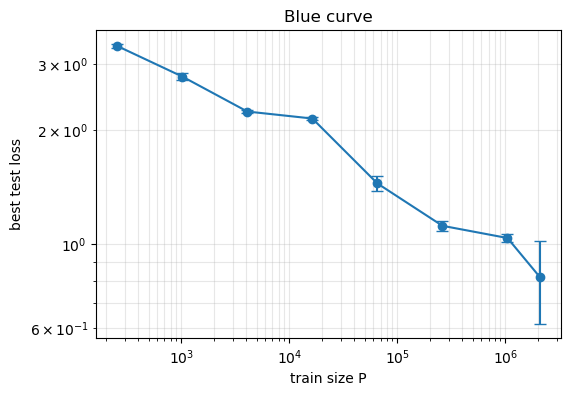

In [5]:
P = res["P_values"]
y = res["best_loss_mean"]
yerr = np.where(res["best_loss_std"] < 0, 0.0, res["best_loss_std"])

plt.figure(figsize=(6, 4))
plt.errorbar(P, y, yerr=yerr, marker="o", capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("train size P")
plt.ylabel("best test loss")
plt.title("Blue curve")
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_4656/2940205036.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("viridis")


(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'test error vs spectral complexity norm'}, xlabel='spectral complexity norm', ylabel='test error'>)

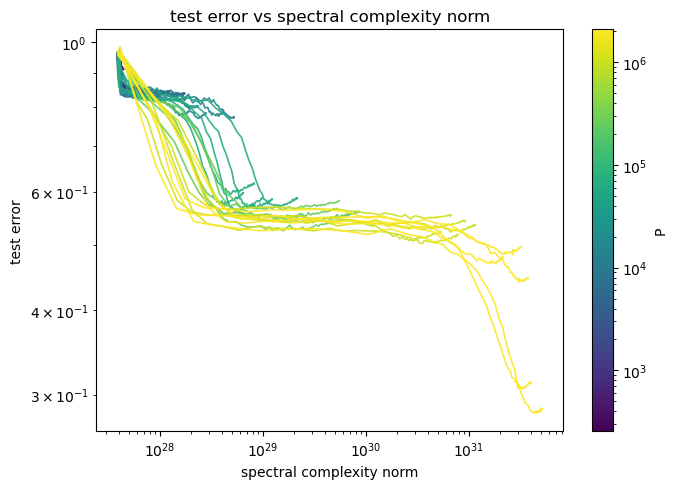

In [6]:
plot_err_vs_norm_all_curves(
    res,
    norm_type="spectral_complexity",
    xscale="log",
    yscale="log",
)


{'t': 0, 'trainloss': 3.587666044011712, 'testloss': 3.5882899686694145, 'testacc': 0.0301513671875, 'specnorm': 4.0394382073224945e+27, 'l2norm': 1782.8037109375}
{'t': 64, 'trainloss': 0.17005703088943847, 'testloss': 2.6595407351851463, 'testacc': 0.415435791015625, 'specnorm': 1.2355686557323425e+29, 'l2norm': 1862.5472412109375}
dict_keys(['t', 'trainloss', 'testloss', 'testacc', 'specnorm', 'l2norm'])
